# **FASE 1 - Set up Env**  
1. Mount Google Drive
2. Konfigurasi skenario dan path
3. Generate dan jalankan `setup_env.sh` (Java, Hadoop, Spark, SSH)
4. Set environment variables
5. Verifikasi instalasi dasar


### **1. Mount Google Drive**

In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


### **2. Konfigurasi Skenario dan Path**

In [ ]:
from pathlib import Path

# Konfigurasi skenario - ubah dua baris ini
NUM_WORKERS = 2
NUM_PARTITIONS = 2
EPOCHS = 15

SCENARIO_NAME = f"{NUM_WORKERS}W{NUM_PARTITIONS}P"

# Versi komponen
HADOOP_VERSION = "3.3.6"
SPARK_VERSION = "3.5.5"
SPARK_HADOOP_PROFILE = "hadoop3"

SSH_PORT = 2222

# Path instalasi (ephemeral, reset tiap sesi Colab baru)
INSTALL_DIR = Path("/content")
HADOOP_HOME = INSTALL_DIR / "hadoop"
SPARK_HOME = INSTALL_DIR / "spark"
HADOOP_CONF_DIR = HADOOP_HOME / "etc" / "hadoop"

DATA_DIR = INSTALL_DIR / "hadoop_data"
NAMENODE_DIR = DATA_DIR / "namenode"
DATANODE_DIR = DATA_DIR / "datanode"

HDFS_WORKDIR = "/user/skincancer/raw"

# Path di Drive (persisten antar sesi, dipakai sebagai cache)
PROJECT_DIR = Path("/content/drive/MyDrive/riset_kanker_kulit")
CACHE_DIR = PROJECT_DIR / "cache"
SCRIPT_DIR = PROJECT_DIR / "scripts"
SETUP_SCRIPT_PATH = SCRIPT_DIR / "setup_env.sh"

PROJECT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)
SCRIPT_DIR.mkdir(parents=True, exist_ok=True)

print(f"Skenario: {SCENARIO_NAME}")
print(f"Hadoop {HADOOP_VERSION} -> {HADOOP_HOME}")
print(f"Spark {SPARK_VERSION} -> {SPARK_HOME}")

Skenario: 2W2P
Hadoop 3.3.6 -> /content/hadoop
Spark 3.5.5 -> /content/spark


### **3. Generate dan Jalankan `setup_env.sh`**

Idempotent, dengan cache tarball Hadoop/Spark di Drive supaya run kedua dan seterusnya tidak perlu download ulang.

In [ ]:
SETUP_SCRIPT = f"""#!/bin/bash
# Idempotent environment setup: Java 11, Hadoop, Spark, SSH.
# Safe to re-run every Colab session.

set -e

HADOOP_VERSION="{HADOOP_VERSION}"
SPARK_VERSION="{SPARK_VERSION}"
SPARK_HADOOP_PROFILE="{SPARK_HADOOP_PROFILE}"

INSTALL_DIR="{INSTALL_DIR}"
HADOOP_HOME="{HADOOP_HOME}"
SPARK_HOME="{SPARK_HOME}"
CACHE_DIR="{CACHE_DIR}"

HADOOP_ARCHIVE="hadoop-${{HADOOP_VERSION}}.tar.gz"
SPARK_ARCHIVE="spark-${{SPARK_VERSION}}-bin-${{SPARK_HADOOP_PROFILE}}.tgz"

HADOOP_URL="https://archive.apache.org/dist/hadoop/common/hadoop-${{HADOOP_VERSION}}/${{HADOOP_ARCHIVE}}"
SPARK_URL="https://archive.apache.org/dist/spark/spark-${{SPARK_VERSION}}/${{SPARK_ARCHIVE}}"

mkdir -p "${{CACHE_DIR}}"

fetch_archive() {{
    local archive_name="$1"
    local url="$2"
    local local_path="${{INSTALL_DIR}}/${{archive_name}}"
    local cache_path="${{CACHE_DIR}}/${{archive_name}}"

    if [ -f "${{local_path}}" ]; then
        return 0
    fi

    if [ -f "${{cache_path}}" ]; then
        echo "Using cached ${{archive_name}} from Drive"
        cp "${{cache_path}}" "${{local_path}}"
    else
        echo "Downloading ${{archive_name}}"
        wget -q "${{url}}" -O "${{local_path}}"
        cp "${{local_path}}" "${{cache_path}}"
    fi
}}

echo "== Java =="
dpkg -s openjdk-11-jdk-headless >/dev/null 2>&1 || {{
    apt-get update -qq
    apt-get install -y -qq openjdk-11-jdk-headless
}}

echo "== Hadoop ${{HADOOP_VERSION}} =="
if [ ! -d "${{HADOOP_HOME}}" ]; then
    fetch_archive "${{HADOOP_ARCHIVE}}" "${{HADOOP_URL}}"
    tar -xzf "${{INSTALL_DIR}}/${{HADOOP_ARCHIVE}}" -C "${{INSTALL_DIR}}"
    mv "${{INSTALL_DIR}}/hadoop-${{HADOOP_VERSION}}" "${{HADOOP_HOME}}"
fi

echo "== Spark ${{SPARK_VERSION}} =="
if [ ! -d "${{SPARK_HOME}}" ]; then
    fetch_archive "${{SPARK_ARCHIVE}}" "${{SPARK_URL}}"
    tar -xzf "${{INSTALL_DIR}}/${{SPARK_ARCHIVE}}" -C "${{INSTALL_DIR}}"
    mv "${{INSTALL_DIR}}/spark-${{SPARK_VERSION}}-bin-${{SPARK_HADOOP_PROFILE}}" "${{SPARK_HOME}}"
fi

echo "== SSH =="
dpkg -s openssh-server >/dev/null 2>&1 || apt-get install -y -qq openssh-server openssh-client
mkdir -p /var/run/sshd ~/.ssh

ssh-keygen -A  # generate host key server - sering belum ada di container baru, ini penyebab "connection refused"

[ -f ~/.ssh/id_rsa ] || ssh-keygen -t rsa -P '' -f ~/.ssh/id_rsa -q
touch ~/.ssh/authorized_keys
grep -qxF "$(cat ~/.ssh/id_rsa.pub)" ~/.ssh/authorized_keys || cat ~/.ssh/id_rsa.pub >> ~/.ssh/authorized_keys
chmod 700 ~/.ssh
chmod 600 ~/.ssh/authorized_keys

service ssh restart

echo "Setup finished: Java 11, Hadoop ${{HADOOP_VERSION}}, Spark ${{SPARK_VERSION}}, SSH ready"
"""

SETUP_SCRIPT_PATH.write_text(SETUP_SCRIPT)
SETUP_SCRIPT_PATH.chmod(0o755)

print(f"Script written to {SETUP_SCRIPT_PATH}")

Script written to /content/drive/MyDrive/riset_kanker_kulit/scripts/setup_env.sh


In [ ]:
!bash "{SETUP_SCRIPT_PATH}"

== Java ==
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package openjdk-11-jre-headless:amd64.
(Reading database ... 118419 files and directories currently installed.)
Preparing to unpack .../openjdk-11-jre-headless_11.0.32+9-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jre-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
Selecting previously unselected package openjdk-11-jdk-headless:amd64.
Preparing to unpack .../openjdk-11-jdk-headless_11.0.32+9-1ubuntu1~22.04_amd64.deb ...
Unpacking openjdk-11-jdk-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
Setting up openjdk-11-jre-headless:amd64 (11.0.32+9-1ubuntu1~22.04) ...
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/jjs to provide /usr/bin/jjs (jjs) in auto mode
update-alternatives: using /usr/lib/jvm/java-11-openjdk-amd64/bin/rmid to provide /u

### **4. Set Environment Variables**

`JAVA_HOME` dideteksi otomatis dari lokasi binary `java`, bukan di-hardcode.

In [ ]:
import os
import subprocess

def resolve_java_home() -> str:
    candidate = Path("/usr/lib/jvm/java-11-openjdk-amd64")
    if candidate.exists():
        return str(candidate)

    alternatives = subprocess.run(
        ["update-alternatives", "--list", "java"], capture_output=True, text=True
    ).stdout.splitlines()
    for path in alternatives:
        if "java-11" in path:
            return str(Path(path).parent.parent)

    which_java = subprocess.run(
        ["which", "java"], capture_output=True, text=True, check=True
    ).stdout.strip()
    real_java = subprocess.run(
        ["readlink", "-f", which_java], capture_output=True, text=True, check=True
    ).stdout.strip()
    return str(Path(real_java).parent.parent)

os.environ["JAVA_HOME"] = resolve_java_home()
os.environ["HADOOP_HOME"] = str(HADOOP_HOME)
os.environ["SPARK_HOME"] = str(SPARK_HOME)
os.environ["HADOOP_CONF_DIR"] = str(HADOOP_CONF_DIR)
os.environ["LD_LIBRARY_PATH"] = str(HADOOP_HOME / "lib" / "native")

os.environ["PATH"] = ":".join([
    f"{os.environ['JAVA_HOME']}/bin",
    f"{os.environ['HADOOP_HOME']}/bin",
    f"{os.environ['HADOOP_HOME']}/sbin",
    f"{os.environ['SPARK_HOME']}/bin",
    f"{os.environ['SPARK_HOME']}/sbin",
    os.environ["PATH"],
])

print(f"JAVA_HOME = {os.environ['JAVA_HOME']}")
print(f"HADOOP_HOME = {os.environ['HADOOP_HOME']}")

JAVA_HOME = /usr/lib/jvm/java-11-openjdk-amd64
HADOOP_HOME = /content/hadoop


### **5. Verifikasi Instalasi Dasar**

In [ ]:
!java -version
!$HADOOP_HOME/bin/hadoop version
!$SPARK_HOME/bin/spark-submit --version
!ssh -o StrictHostKeyChecking=no -p {SSH_PORT} localhost "echo SSH connection OK"

openjdk version "11.0.32" 2026-07-21
OpenJDK Runtime Environment (build 11.0.32+9-post-1ubuntu1-22.04-Ubuntu)
OpenJDK 64-Bit Server VM (build 11.0.32+9-post-1ubuntu1-22.04-Ubuntu, mixed mode, sharing)
Hadoop 3.3.6
Source code repository https://github.com/apache/hadoop.git -r 1be78238728da9266a4f88195058f08fd012bf9c
Compiled by ubuntu on 2023-06-18T08:22Z
Compiled on platform linux-x86_64
Compiled with protoc 3.7.1
From source with checksum 5652179ad55f76cb287d9c633bb53bbd
This command was run using /content/hadoop/share/hadoop/common/hadoop-common-3.3.6.jar
Welcome to
      ____              __
     / __/__  ___ _____/ /__
    _\ \/ _ \/ _ `/ __/  '_/
   /___/ .__/\_,_/_/ /_/\_\   version 3.5.5
      /_/
                        
Using Scala version 2.12.18, OpenJDK 64-Bit Server VM, 11.0.32
Branch HEAD
Compiled by user ubuntu on 2025-02-23T20:30:46Z
Revision 7c29c664cdc9321205a98a14858aaf8daaa19db2
Url https://github.com/apache/spark
Type --help for more information.
SSH connection OK

# **Fase 2 - Konfigurasi HDFS**
6. `core-site.xml`
7. `hdfs-site.xml` dan `JAVA_HOME` di `hadoop-env.sh`
8. Format NameNode (idempotent)
9. Start HDFS dan verifikasi
10. Buat direktori kerja di HDFS

### **6. `core-site.xml`**

Menunjuk HDFS ke `localhost:9000` sebagai NameNode.

In [ ]:
CORE_SITE = """<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>fs.defaultFS</name>
        <value>hdfs://localhost:9000</value>
    </property>
</configuration>
"""

core_site_path = HADOOP_CONF_DIR / "core-site.xml"
core_site_path.write_text(CORE_SITE)
print(f"Written: {core_site_path}")

Written: /content/hadoop/etc/hadoop/core-site.xml


### **7. `hdfs-site.xml`**

`dfs.namenode.name.dir` dan `dfs.datanode.data.dir` diarahkan ke direktori eksplisit (bukan default `/tmp`), dan `dfs.permissions.enabled` dimatikan supaya tidak ada error permission selama eksperimen.

`JAVA_HOME` juga didaftarkan ke `hadoop-env.sh`, karena `start-dfs.sh` memulai daemon lewat SSH ke localhost dan sesi SSH itu tidak mewarisi environment variable dari notebook.

In [ ]:
NAMENODE_DIR.mkdir(parents=True, exist_ok=True)
DATANODE_DIR.mkdir(parents=True, exist_ok=True)

HDFS_SITE = f"""<?xml version="1.0" encoding="UTF-8"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>dfs.replication</name>
        <value>1</value>
    </property>
    <property>
        <name>dfs.namenode.name.dir</name>
        <value>file://{NAMENODE_DIR}</value>
    </property>
    <property>
        <name>dfs.datanode.data.dir</name>
        <value>file://{DATANODE_DIR}</value>
    </property>
    <property>
        <name>dfs.permissions.enabled</name>
        <value>false</value>
    </property>
    <property>
        <name>dfs.namenode.secondary.http-address</name>
        <value>localhost:9868</value>
    </property>
</configuration>
"""

hdfs_site_path = HADOOP_CONF_DIR / "hdfs-site.xml"
hdfs_site_path.write_text(HDFS_SITE)
print(f"Written: {hdfs_site_path}")

hadoop_env_path = HADOOP_CONF_DIR / "hadoop-env.sh"

env_exports = {
    "JAVA_HOME": os.environ["JAVA_HOME"],
    "HADOOP_SSH_OPTS": f"-p {SSH_PORT}",
    "HDFS_NAMENODE_USER": "root",
    "HDFS_DATANODE_USER": "root",
    "HDFS_SECONDARYNAMENODE_USER": "root",
    "YARN_RESOURCEMANAGER_USER": "root",
    "YARN_NODEMANAGER_USER": "root",
}

lines = [
    line for line in hadoop_env_path.read_text().splitlines()
    if not any(line.strip().startswith(f"export {key}=") for key in env_exports)
]
for key, value in env_exports.items():
    lines.append(f'export {key}="{value}"')

hadoop_env_path.write_text("\n".join(lines) + "\n")
print(f"Environment variables terdaftar di {hadoop_env_path}: {list(env_exports.keys())}")

Written: /content/hadoop/etc/hadoop/hdfs-site.xml
Environment variables terdaftar di /content/hadoop/etc/hadoop/hadoop-env.sh: ['JAVA_HOME', 'HADOOP_SSH_OPTS', 'HDFS_NAMENODE_USER', 'HDFS_DATANODE_USER', 'HDFS_SECONDARYNAMENODE_USER', 'YARN_RESOURCEMANAGER_USER', 'YARN_NODEMANAGER_USER']


### **8. Format NameNode**

Dilewati otomatis kalau sudah pernah diformat sebelumnya di sesi ini.

In [ ]:
version_file = NAMENODE_DIR / "current" / "VERSION"

if version_file.exists():
    print("NameNode sudah pernah diformat, dilewati.")
else:
    print("Memformat NameNode...")
    result = subprocess.run(
        [str(HADOOP_HOME / "bin" / "hdfs"), "namenode", "-format", "-force"],
        capture_output=True,
        text=True,
    )
    if result.returncode != 0:
        print(result.stdout)
        print(result.stderr)
        raise RuntimeError("Format NameNode gagal")
    print("NameNode berhasil diformat.")

Memformat NameNode...
NameNode berhasil diformat.


### **9. Start HDFS dan Verifikasi**

In [ ]:
!$HADOOP_HOME/sbin/start-dfs.sh

Starting namenodes on [localhost]
Starting datanodes
Starting secondary namenodes [localhost]


In [ ]:
def check_jps(expected_processes):
    output = subprocess.run(["jps"], capture_output=True, text=True).stdout
    print(output)
    for name in expected_processes:
        status = "OK" if name in output else "MISSING"
        print(f"{name}: {status}")

check_jps(["NameNode", "DataNode"])

4497 SecondaryNameNode
4707 Jps
4195 NameNode
4295 DataNode

NameNode: OK
DataNode: OK


### **10. Buat Direktori Kerja di HDFS**

In [ ]:
!hdfs dfs -mkdir -p {HDFS_WORKDIR}
!hdfs dfs -ls -R /user/skincancer
!hdfs dfsadmin -report

drwxr-xr-x   - root supergroup          0 2026-08-31 01:03 /user/skincancer/raw
Configured Capacity: 115658190848 (107.72 GB)
Present Capacity: 89570603008 (83.42 GB)
DFS Remaining: 89570578432 (83.42 GB)
DFS Used: 24576 (24 KB)
DFS Used%: 0.00%
Replicated Blocks:
	Under replicated blocks: 0
	Blocks with corrupt replicas: 0
	Missing blocks: 0
	Missing blocks (with replication factor 1): 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0
Erasure Coded Block Groups: 
	Low redundancy block groups: 0
	Block groups with corrupt internal blocks: 0
	Missing block groups: 0
	Low redundancy blocks with highest priority to recover: 0
	Pending deletion blocks: 0

-------------------------------------------------
Live datanodes (1):

Name: 127.0.0.1:9866 (localhost)
Hostname: 0ed1c28bedf3
Decommission Status : Normal
Configured Capacity: 115658190848 (107.72 GB)
DFS Used: 24576 (24 KB)
Non DFS Used: 26070810624 (24.28 GB)
DFS Remaining: 89570578432 (83.42 GB)


# **FASE 3 — Konfigurasi YARN**

### **11. Cek Kapasitas Aktual Colab**

In [ ]:
!nproc
!free -h

2
               total        used        free      shared  buff/cache   available
Mem:            12Gi       1.9Gi       382Mi       2.0Mi        10Gi        10Gi
Swap:             0B          0B          0B


### **12. Hitung Alokasi Resource YARN dan Executor**

In [ ]:
import subprocess

cpu_count = int(subprocess.run(["nproc"], capture_output=True, text=True).stdout.strip())

free_lines = subprocess.run(["free", "-m"], capture_output=True, text=True).stdout.splitlines()
total_mem_mb = int(free_lines[1].split()[1])

# Sisakan RAM untuk OS, kernel Jupyter, dan proses SSH/Colab lainnya
RESERVED_MEM_MB = 2048
YARN_NM_MEMORY_MB = max(total_mem_mb - RESERVED_MEM_MB, 1024)

# Skenario terberat yang direncanakan adalah 8 worker (8x2, 8x8). vcores
# NodeManager dibuat mengikuti angka ini walau CPU fisik lebih sedikit -
# vcore YARN adalah unit penjadwalan, bukan pin fisik, jadi 8 worker tetap
# bisa dijadwalkan meski bergantian memakai CPU yang sama.
MAX_WORKERS_PLANNED = 8
YARN_NM_VCORES = max(cpu_count, MAX_WORKERS_PLANNED)

# Resource per executor konstan untuk semua skenario, dihitung dari kasus
# terberat supaya aman di skenario manapun.
container_memory_mb = YARN_NM_MEMORY_MB // MAX_WORKERS_PLANNED
EXECUTOR_MEMORY_OVERHEAD_MB = max(384, int(container_memory_mb * 0.1))
EXECUTOR_MEMORY_MB = max(container_memory_mb - EXECUTOR_MEMORY_OVERHEAD_MB, 256)
EXECUTOR_CORES = 1

print(f"CPU fisik: {cpu_count}, RAM total: {total_mem_mb} MB")
print(f"YARN NodeManager: {YARN_NM_MEMORY_MB} MB, {YARN_NM_VCORES} vcores")
print(f"Per executor (konstan semua skenario): {EXECUTOR_MEMORY_MB} MB + {EXECUTOR_MEMORY_OVERHEAD_MB} MB overhead, {EXECUTOR_CORES} core")

CPU fisik: 2, RAM total: 12975 MB
YARN NodeManager: 10927 MB, 8 vcores
Per executor (konstan semua skenario): 981 MB + 384 MB overhead, 1 core


### **13. yarn-site.xml**

In [ ]:
# yarn.nodemanager.vmem-check-enabled dimatikan karena di lingkungan virtual seperti Colab,
# pengecekan virtual memory YARN sering salah men-deteksi container sehat sebagai over-limit dan mematikannya.

YARN_SITE = f"""<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>yarn.nodemanager.aux-services</name>
        <value>mapreduce_shuffle</value>
    </property>
    <property>
        <name>yarn.nodemanager.aux-services.mapreduce.shuffle.class</name>
        <value>org.apache.hadoop.mapred.ShuffleHandler</value>
    </property>
    <property>
        <name>yarn.nodemanager.resource.memory-mb</name>
        <value>{YARN_NM_MEMORY_MB}</value>
    </property>
    <property>
        <name>yarn.nodemanager.resource.cpu-vcores</name>
        <value>{YARN_NM_VCORES}</value>
    </property>
    <property>
        <name>yarn.nodemanager.vmem-check-enabled</name>
        <value>false</value>
    </property>
</configuration>
"""

yarn_site_path = HADOOP_CONF_DIR / "yarn-site.xml"
yarn_site_path.write_text(YARN_SITE)
print(f"Written: {yarn_site_path}")

Written: /content/hadoop/etc/hadoop/yarn-site.xml


### **14. mapred-site.xml**

In [ ]:
MAPRED_SITE = """<?xml version="1.0"?>
<?xml-stylesheet type="text/xsl" href="configuration.xsl"?>
<configuration>
    <property>
        <name>mapreduce.framework.name</name>
        <value>yarn</value>
    </property>
</configuration>
"""

mapred_site_path = HADOOP_CONF_DIR / "mapred-site.xml"
mapred_site_path.write_text(MAPRED_SITE)
print(f"Written: {mapred_site_path}")

Written: /content/hadoop/etc/hadoop/mapred-site.xml


### **15. Start YARN n Verifikasi**

In [ ]:
!$HADOOP_HOME/sbin/start-yarn.sh

Starting resourcemanager
Starting nodemanagers


In [ ]:
check_jps(["ResourceManager", "NodeManager"])

4497 SecondaryNameNode
4195 NameNode
5236 Jps
4295 DataNode
5017 ResourceManager
5117 NodeManager

ResourceManager: OK
NodeManager: OK


### **16. Stage Spark Jars ke HDFS**

In [ ]:
import shutil

SPARK_ARCHIVE_HDFS_PATH = "/user/spark/spark-libs.zip"
spark_libs_zip = INSTALL_DIR / "spark-libs.zip"

if not spark_libs_zip.exists():
    print("Packing Spark jars...")
    shutil.make_archive(str(spark_libs_zip.with_suffix("")), "zip", str(SPARK_HOME / "jars"))

subprocess.run(["hdfs", "dfs", "-mkdir", "-p", "/user/spark"], check=True)
subprocess.run(["hdfs", "dfs", "-put", "-f", str(spark_libs_zip), SPARK_ARCHIVE_HDFS_PATH], check=True)
print(f"Spark jars staged at hdfs://localhost:9000{SPARK_ARCHIVE_HDFS_PATH}")

Packing Spark jars...
Spark jars staged at hdfs://localhost:9000/user/spark/spark-libs.zip


### **17. spark-defaults.conf**

In [ ]:
SPARK_DEFAULTS = f"""spark.master                     yarn
spark.submit.deployMode          client
spark.yarn.archive               hdfs://localhost:9000{SPARK_ARCHIVE_HDFS_PATH}
spark.executor.instances         {NUM_WORKERS}
spark.executor.cores             {EXECUTOR_CORES}
spark.executor.memory            {EXECUTOR_MEMORY_MB}m
spark.executor.memoryOverhead    {EXECUTOR_MEMORY_OVERHEAD_MB}m
spark.driver.memory              1g
"""

spark_defaults_path = SPARK_HOME / "conf" / "spark-defaults.conf"
spark_defaults_path.write_text(SPARK_DEFAULTS)
print(f"Written: {spark_defaults_path}")
print(SPARK_DEFAULTS)

Written: /content/spark/conf/spark-defaults.conf
spark.master                     yarn
spark.submit.deployMode          client
spark.yarn.archive               hdfs://localhost:9000/user/spark/spark-libs.zip
spark.executor.instances         2
spark.executor.cores             1
spark.executor.memory            981m
spark.executor.memoryOverhead    384m
spark.driver.memory              1g



### **18. Verifikasi: Submit Job ke YARN**

jika muncul baris Pi is roughly 3.14... di output tandanya cluster YARN pseudo-distributed sudah aktif dan bisa menjalankan job Spark.

In [ ]:
!$SPARK_HOME/bin/spark-submit \
  --master yarn \
  --deploy-mode client \
  --class org.apache.spark.examples.SparkPi \
  $SPARK_HOME/examples/jars/spark-examples_*.jar 10

26/08/31 01:04:41 INFO SparkContext: Running Spark version 3.5.5
26/08/31 01:04:41 INFO SparkContext: OS info Linux, 6.6.122+, amd64
26/08/31 01:04:41 INFO SparkContext: Java version 11.0.32
26/08/31 01:04:42 INFO ResourceUtils: ==============================================================
26/08/31 01:04:42 INFO ResourceUtils: No custom resources configured for spark.driver.
26/08/31 01:04:42 INFO ResourceUtils: ==============================================================
26/08/31 01:04:42 INFO SparkContext: Submitted application: Spark Pi
26/08/31 01:04:42 INFO ResourceProfile: Default ResourceProfile created, executor resources: Map(memoryOverhead -> name: memoryOverhead, amount: 384, script: , vendor: , cores -> name: cores, amount: 1, script: , vendor: , memory -> name: memory, amount: 981, script: , vendor: , offHeap -> name: offHeap, amount: 0, script: , vendor: ), task resources: Map(cpus -> name: cpus, amount: 1.0)
26/08/31 01:04:42 INFO ResourceProfile: Limiting resource is

# **FASE 4 — Dataset (Kaggle → Colab → HDFS)**

### **19. Konfigurasi Dataset dan Kredensial Kaggle**



In [ ]:
HAM10000_SLUG = "kmader/skin-cancer-mnist-ham10000"
ISIC2017_SLUG = "wanderdust/skin-lesion-analysis-toward-melanoma-detection"

CLASS_NAMES = ["nevus", "melanoma", "seborrheic_keratosis"]
NUM_CLASSES = len(CLASS_NAMES)

# HAM10000 dipakai sebagai tambahan data untuk 2 kelas ini saja (dx code -> kelas kita).
# Kelas "nevus" seluruhnya diambil dari ISIC2017 - HAM10000 tidak dipakai untuk nevus.
HAM10000_DX_TO_CLASS = {
    "mel": "melanoma",
    "bkl": "seborrheic_keratosis",
}

DATASET_LOCAL_DIR = INSTALL_DIR / "dataset_raw"
MERGED_DATASET_DIR = INSTALL_DIR / "dataset_merged"
DATASET_LOCAL_DIR.mkdir(parents=True, exist_ok=True)
MERGED_DATASET_DIR.mkdir(parents=True, exist_ok=True)

HAM10000_DIR = DATASET_LOCAL_DIR / "ham10000"
ISIC2017_DIR = DATASET_LOCAL_DIR / "isic2017"

KAGGLE_JSON_DRIVE_PATH = PROJECT_DIR / "kaggle.json"

assert KAGGLE_JSON_DRIVE_PATH.exists(), (
    f"{KAGGLE_JSON_DRIVE_PATH} tidak ditemukan. "
    "Ambil token dari kaggle.com/settings > Create New Token, lalu upload kaggle.json ke path ini."
)

### **20. Setup Kaggle API dan Download Dataset**

In [ ]:
import shutil
import csv

kaggle_dir = Path.home() / ".kaggle"
kaggle_dir.mkdir(exist_ok=True)
kaggle_json_path = kaggle_dir / "kaggle.json"

shutil.copy(KAGGLE_JSON_DRIVE_PATH, kaggle_json_path)
kaggle_json_path.chmod(0o600)

subprocess.run(["pip", "install", "-q", "kaggle"], check=True)

def download_kaggle_dataset(slug, target_dir):
    target_dir = Path(target_dir)
    if target_dir.exists() and any(target_dir.iterdir()):
        print(f"{target_dir} sudah berisi data, download dilewati.")
        return
    target_dir.mkdir(parents=True, exist_ok=True)
    print(f"Downloading {slug}...")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", slug, "-p", str(target_dir), "--unzip"],
        check=True,
    )

download_kaggle_dataset(HAM10000_SLUG, HAM10000_DIR)
download_kaggle_dataset(ISIC2017_SLUG, ISIC2017_DIR)

### **21. Extract Dataset dan Cek Struktur Folder**

struktur apa pun yang kamu buat di Kaggle akan langsung kelihatan di sini untuk dicek manual sebelum lanjut upload.

In [ ]:
def collect_isic_images(isic_root, class_names):
    records = []
    base = Path(isic_root) / "skin-lesions"
    if not base.exists():
        base = Path(isic_root)  # fallback jika struktur zip berbeda

    for split_dir in base.iterdir():
        if not split_dir.is_dir():
            continue
        for class_name in class_names:
            class_dir = split_dir / class_name
            if not class_dir.exists():
                continue
            for image_path in class_dir.iterdir():
                if image_path.suffix.lower() in (".jpg", ".jpeg", ".png"):
                    records.append((image_path, class_name))
    return records


def collect_ham10000_images(ham_root, dx_to_class):
    metadata_csv = next(Path(ham_root).glob("*metadata*.csv"))
    image_dirs = [d for d in Path(ham_root).iterdir() if d.is_dir()]

    image_index = {}
    for image_dir in image_dirs:
        for image_path in image_dir.rglob("*.jpg"):
            image_index[image_path.stem] = image_path

    records = []
    with open(metadata_csv) as f:
        for row in csv.DictReader(f):
            dx = row["dx"]
            if dx not in dx_to_class:
                continue
            image_path = image_index.get(row["image_id"])
            if image_path is not None:
                records.append((image_path, dx_to_class[dx]))
    return records


def build_merged_dataset(class_names):
    isic_records = [(p, c, "ISIC2017") for p, c in collect_isic_images(ISIC2017_DIR, class_names)]
    ham_records = [(p, c, "HAM10000") for p, c in collect_ham10000_images(HAM10000_DIR, HAM10000_DX_TO_CLASS)]
    all_records = isic_records + ham_records

    for class_name in class_names:
        (MERGED_DATASET_DIR / class_name).mkdir(parents=True, exist_ok=True)

    manifest_path = PROJECT_DIR / "dataset_manifest.csv"
    with open(manifest_path, "w", newline="") as f:
        writer = csv.writer(f)
        writer.writerow(["filename", "class", "source"])
        for image_path, class_name, source in all_records:
            dest = MERGED_DATASET_DIR / class_name / image_path.name
            if not dest.exists():
                dest.symlink_to(image_path.resolve())
            writer.writerow([image_path.name, class_name, source])

    return all_records


if any(MERGED_DATASET_DIR.rglob("*")):
    print(f"{MERGED_DATASET_DIR} sudah berisi hasil gabungan, dilewati.")
else:
    manifest = build_merged_dataset(CLASS_NAMES)
    print(f"Total citra tergabung: {len(manifest)}")

for class_name in CLASS_NAMES:
    count = sum(1 for _ in (MERGED_DATASET_DIR / class_name).iterdir())
    print(f"  {class_name}: {count} file")

Total citra tergabung: 4962
  nevus: 1843 file
  melanoma: 1634 file
  seborrheic_keratosis: 1485 file


### **22. Upload Dataset ke HDFS**

In [ ]:
class_folders = [MERGED_DATASET_DIR / name for name in CLASS_NAMES]

existing = subprocess.run(
    ["hdfs", "dfs", "-ls", HDFS_WORKDIR], capture_output=True, text=True
).stdout.strip()

if existing:
    print(f"{HDFS_WORKDIR} sudah berisi data di HDFS, upload dilewati.")
else:
    print("Uploading dataset ke HDFS...")
    for class_folder in class_folders:
        subprocess.run(
            ["hdfs", "dfs", "-put", str(class_folder), f"{HDFS_WORKDIR}/"],
            check=True,
        )
    print("Upload selesai.")

Uploading dataset ke HDFS...
Upload selesai.


### **23. Verifikasi Dataset di HDFS**

In [ ]:
!hdfs dfs -ls -R {HDFS_WORKDIR}
!hdfs dfs -du -h {HDFS_WORKDIR}

drwxr-xr-x   - root supergroup          0 2026-08-31 01:39 /user/skincancer/raw/melanoma
-rw-r--r--   1 root supergroup      57838 2026-08-31 01:37 /user/skincancer/raw/melanoma/ISIC_0000002.jpg
-rw-r--r--   1 root supergroup      49365 2026-08-31 01:39 /user/skincancer/raw/melanoma/ISIC_0000004.jpg
-rw-r--r--   1 root supergroup      34899 2026-08-31 01:36 /user/skincancer/raw/melanoma/ISIC_0000013.jpg
-rw-r--r--   1 root supergroup      99491 2026-08-31 01:36 /user/skincancer/raw/melanoma/ISIC_0000022.jpg
-rw-r--r--   1 root supergroup      71077 2026-08-31 01:34 /user/skincancer/raw/melanoma/ISIC_0000026.jpg
-rw-r--r--   1 root supergroup     106003 2026-08-31 01:36 /user/skincancer/raw/melanoma/ISIC_0000029.jpg
-rw-r--r--   1 root supergroup      95086 2026-08-31 01:37 /user/skincancer/raw/melanoma/ISIC_0000030.jpg
-rw-r--r--   1 root supergroup     106889 2026-08-31 01:36 /user/skincancer/raw/melanoma/ISIC_0000031.jpg
-rw-r--r--   1 root supergroup      92772 2026-08-31 01:37 /use

### **24. Ringkasan Jumlah File dan Ukuran per Kelas**

In [ ]:
def summarize_hdfs_classes(hdfs_root: str):
    listing = subprocess.run(
        ["hdfs", "dfs", "-ls", hdfs_root], capture_output=True, text=True
    ).stdout
    class_dirs = [line.split()[-1] for line in listing.splitlines() if line.startswith("d")]

    summary = []
    for class_dir in class_dirs:
        count_out = subprocess.run(
            ["hdfs", "dfs", "-count", class_dir], capture_output=True, text=True
        ).stdout.split()
        file_count = int(count_out[1])

        du_out = subprocess.run(
            ["hdfs", "dfs", "-du", "-s", class_dir], capture_output=True, text=True
        ).stdout.split()
        size_mb = int(du_out[0]) / (1024 * 1024)

        summary.append((class_dir.rstrip("/").split("/")[-1], file_count, size_mb))

    print(f"{'Kelas':<20}{'Jumlah File':>15}{'Ukuran (MB)':>15}")
    for name, count, size_mb in summary:
        print(f"{name:<20}{count:>15}{size_mb:>15.1f}")

    counts = [c for _, c, _ in summary]
    ratio = max(counts) / min(counts) if min(counts) else float("inf")
    print(f"\nRasio imbalance (kelas terbanyak / tersedikit): {ratio:.2f}")
    if ratio > 3:
        print("Imbalance cukup besar - pertimbangkan class weighting saat training di Fase 6.")

    return summary

dataset_summary = summarize_hdfs_classes(HDFS_WORKDIR)

Kelas                   Jumlah File    Ukuran (MB)
melanoma                       1634         2507.1
nevus                          1843         7949.8
seborrheic_keratosis           1485         1781.4

Rasio imbalance (kelas terbanyak / tersedikit): 1.24


#### **24.1. Analisis Lanjutan Dataset (Distribusi Block HDFS & Komposisi Sumber)**

In [ ]:
import subprocess
from pathlib import Path
from collections import Counter
import csv

print("==== Distribusi Block HDFS per Kelas ====")
block_size_bytes = int(
    subprocess.run(
        ["hdfs", "getconf", "-confKey", "dfs.blocksize"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()
)
print(f"Ukuran block HDFS: {block_size_bytes / (1024**2):.0f} MB")

def analyze_hdfs_partitions(hdfs_dir, block_size_bytes):
    result = subprocess.run(
        ["hdfs", "dfs", "-ls", "-R", hdfs_dir], capture_output=True, text=True, check=True
    )
    per_class_files, per_class_bytes, per_class_blocks = {}, {}, {}
    for line in result.stdout.splitlines():
        parts = line.split()
        if len(parts) < 8 or parts[0].startswith("d"):
            continue
        size_bytes = int(parts[4])
        class_name = Path(parts[-1]).parent.name
        num_blocks = max(1, -(-size_bytes // block_size_bytes))  # ceil division
        per_class_files[class_name] = per_class_files.get(class_name, 0) + 1
        per_class_bytes[class_name] = per_class_bytes.get(class_name, 0) + size_bytes
        per_class_blocks[class_name] = per_class_blocks.get(class_name, 0) + num_blocks
    return per_class_files, per_class_bytes, per_class_blocks


per_class_files, per_class_bytes, per_class_blocks = analyze_hdfs_partitions(
    HDFS_WORKDIR, block_size_bytes
)

for class_name in CLASS_NAMES:
    files = per_class_files.get(class_name, 0)
    size_mb = per_class_bytes.get(class_name, 0) / (1024**2)
    blocks = per_class_blocks.get(class_name, 0)
    print(f"{class_name:<22} {files:>6} file   {size_mb:>9.1f} MB   {blocks:>4} block")

print("\n==== Komposisi Sumber Dataset per Kelas ====")
source_counts = Counter()
with open(PROJECT_DIR / "dataset_manifest.csv") as f:
    for row in csv.DictReader(f):
        source_counts[(row["class"], row["source"])] += 1

print(f"{'Kelas':<22}{'ISIC2017':>10}{'HAM10000':>10}")
for class_name in CLASS_NAMES:
    isic_count = source_counts.get((class_name, "ISIC2017"), 0)
    ham_count = source_counts.get((class_name, "HAM10000"), 0)
    print(f"{class_name:<22}{isic_count:>10}{ham_count:>10}")

==== Distribusi Block HDFS per Kelas ====
Ukuran block HDFS: 128 MB
nevus                    1843 file      7949.8 MB   1843 block
melanoma                 1634 file      2507.1 MB   1634 block
seborrheic_keratosis     1485 file      1781.4 MB   1485 block

==== Komposisi Sumber Dataset per Kelas ====
Kelas                   ISIC2017  HAM10000
nevus                       1843         0
melanoma                     521      1113
seborrheic_keratosis         386      1099


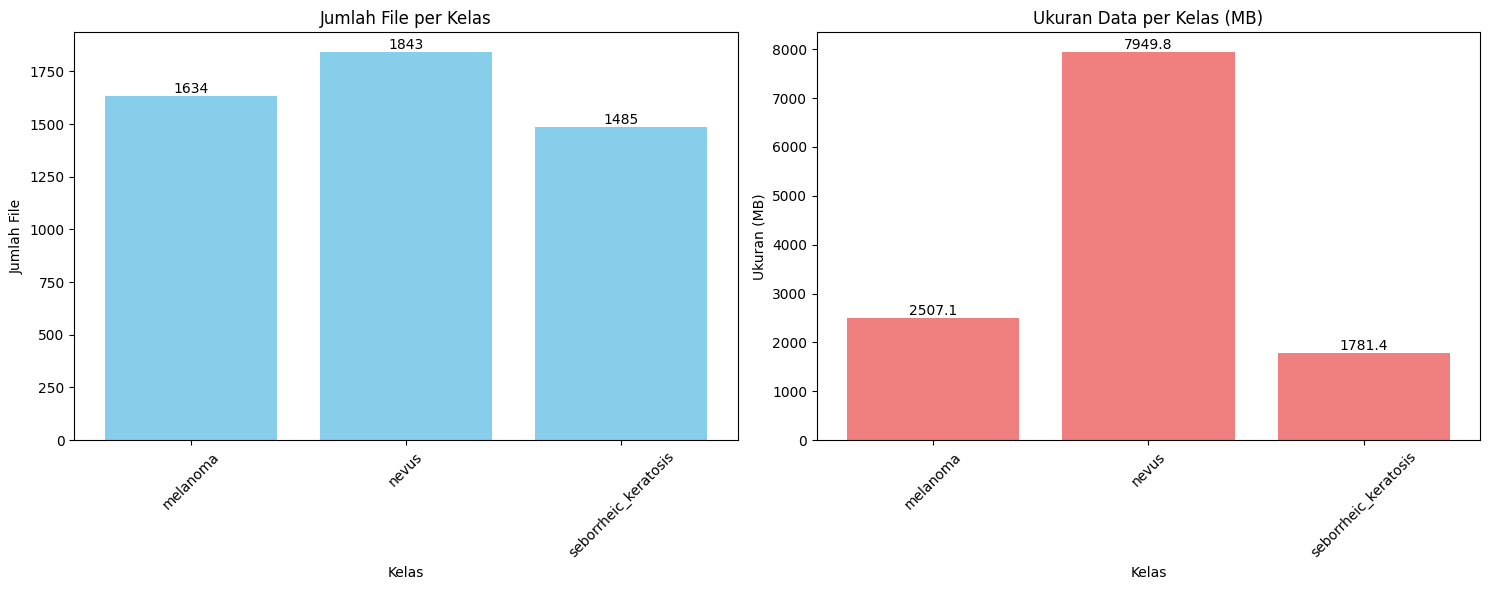

In [ ]:
import matplotlib.pyplot as plt

class_names_plot = [item[0] for item in dataset_summary]
file_counts_plot = [item[1] for item in dataset_summary]
sizes_mb_plot = [item[2] for item in dataset_summary]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plotting file counts
axes[0].bar(class_names_plot, file_counts_plot, color='skyblue')
axes[0].set_title('Jumlah File per Kelas')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah File')
axes[0].tick_params(axis='x', rotation=45)
for index, value in enumerate(file_counts_plot):
    axes[0].text(index, value + 0.1, str(value), ha='center', va='bottom') # Add numbers on top of bars

# Plotting sizes in MB
axes[1].bar(class_names_plot, sizes_mb_plot, color='lightcoral')
axes[1].set_title('Ukuran Data per Kelas (MB)')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Ukuran (MB)')
axes[1].tick_params(axis='x', rotation=45)
for index, value in enumerate(sizes_mb_plot):
    axes[1].text(index, value + 0.1, f'{value:.1f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### **24.2. Contoh Dataset per Kelas**

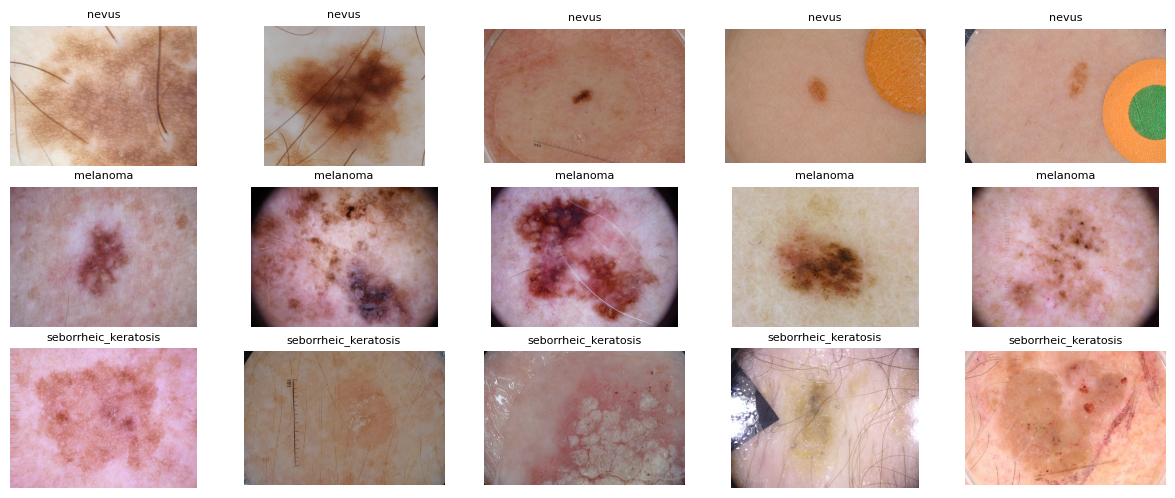

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random

def display_sample_images_per_class(base_dir, class_names, num_samples=3):
    plt.figure(figsize=(15, 6))

    for i, class_name in enumerate(class_names):
        class_path = base_dir / class_name
        if not class_path.exists():
            print(f"Direktori untuk kelas {class_name} tidak ditemukan.")
            continue

        images = list(class_path.glob("*.jpg")) + list(class_path.glob("*.png"))

        if not images:
            print(f"Tidak ada gambar ditemukan di kelas {class_name}.")
            continue

        selected_images = random.sample(images, min(len(images), num_samples))

        for j, img_path in enumerate(selected_images):
            ax = plt.subplot(len(class_names), num_samples, i * num_samples + j + 1)
            img = Image.open(img_path)
            ax.imshow(img)
            ax.set_title(f"{class_name}", fontsize=8)
            ax.axis('off')

    plt.subplots_adjust(hspace=0.15)
    plt.show()

display_sample_images_per_class(MERGED_DATASET_DIR, CLASS_NAMES, num_samples=5)

# **FASE 5 — Pipeline Preprocessing Terdistribusi (PySpark)**

### **25. Inisialisasi PySpark Session**
Sebelum `spark.read.format("binaryFile")`, aktifkan SparkSession. `findspark` menghubungkan notebook ke Spark di `SPARK_HOME` dan otomatis menggunakan konfigurasi `spark-defaults.conf`, termasuk `spark.executor.instances = NUM_WORKERS`.


In [ ]:
import time
import csv

!pip install -q findspark pyarrow
import findspark

findspark.init(str(SPARK_HOME))

from pyspark.sql import SparkSession
from pyspark import StorageLevel

spark = (
    SparkSession.builder
    .appName(f"skincancer-preprocessing-{SCENARIO_NAME}")
    .getOrCreate()
)

print(f"Spark version: {spark.version}")
print(f"Master: {spark.sparkContext.master}")
print(f"Default parallelism: {spark.sparkContext.defaultParallelism}")

Spark version: 3.5.5
Master: yarn
Default parallelism: 2


### **26. Konfigurasi Preprocessing dan Label Mapping**

IMG_SIZE (128x128). `class_names` diambil dari `class_folders` Fase 4 dan diurutkan alfabet agar pemetaan label ke angka tetap konsisten setiap kali dijalankan.


In [ ]:
IMG_SIZE = 128

class_names = sorted(f.name for f in class_folders)
label_to_index = {name: idx for idx, name in enumerate(class_names)}

assert len(class_names) == NUM_CLASSES, (
    f"Ditemukan {len(class_names)} kelas, diharapkan {NUM_CLASSES}"
)

print(f"Class mapping: {label_to_index}")

Class mapping: {'melanoma': 0, 'nevus': 1, 'seborrheic_keratosis': 2}


### **27. Fungsi Modular: Baca, Repartition, dan Preprocessing Terdistribusi**

Import `PIL/numpy` dilakukan sekali per partisi, bukan per baris. Hasil preprocessing di-`persist(MEMORY_AND_DISK)` agar tetap tersebar di executor dan siap digunakan untuk training terdistribusi di Fase 7.


In [ ]:
def run_distributed_preprocessing(spark, hdfs_dir, num_partitions, img_size, label_to_index):
    # 1. Ambil daftar path lewat CLI - ini cuma listing metadata (KB), bukan isi file
    listing = subprocess.run(
        ["hdfs", "dfs", "-ls", "-R", hdfs_dir],
        capture_output=True, text=True, check=True,
    ).stdout

    image_paths = []
    for line in listing.splitlines():
        parts = line.split()
        if len(parts) < 8 or parts[0].startswith("d"):
            continue
        path = parts[-1]
        if path.lower().endswith((".jpg", ".jpeg", ".png")):
            image_paths.append(path)

    if not image_paths:
        raise RuntimeError(f"Tidak ada citra ditemukan di {hdfs_dir}")

    # 2 & 3. RDD ringan berisi path saja - repartition di sini cuma men-shuffle
    # string pendek (~KB total), bukan payload gambar (~GB)
    paths_rdd = spark.sparkContext.parallelize(image_paths).repartition(num_partitions)

    # Dihitung sekali di driver, dikirim ke tiap partisi lewat closure -
    # supaya tidak perlu subprocess/env lookup berulang di dalam tiap worker.
    java_home = os.environ["JAVA_HOME"]
    hadoop_home = str(HADOOP_HOME)
    hadoop_classpath = subprocess.run(
        [f"{hadoop_home}/bin/hadoop", "classpath", "--glob"],
        capture_output=True, text=True, check=True,
    ).stdout.strip()

    def preprocess_partition(paths):
        import os

        # Environment worker tidak otomatis mewarisi punya driver/notebook -
        # didaftarkan eksplisit di sini, sama seperti alasan CUDA_VISIBLE_DEVICES
        # di Fase 7 dan import di dalam build_model().
        os.environ["JAVA_HOME"] = java_home
        os.environ["HADOOP_HOME"] = hadoop_home
        os.environ["LD_LIBRARY_PATH"] = f"{hadoop_home}/lib/native:{java_home}/lib/server"
        os.environ["CLASSPATH"] = hadoop_classpath

        import io
        import numpy as np
        from PIL import Image
        import pyarrow.fs as pafs

        hdfs = pafs.HadoopFileSystem("localhost", port=9000)

        for path in paths:
            try:
                with hdfs.open_input_stream(path) as f:
                    raw_bytes = f.read()

                img = Image.open(io.BytesIO(raw_bytes)).convert("RGB")
                img = img.resize((img_size, img_size))
                array = np.asarray(img, dtype=np.float32) / 255.0

                label_name = path.rstrip("/").split("/")[-2]
                label = label_to_index[label_name]

                yield (array, label)
            except Exception as exc:
                print(f"ERROR memproses {path}: {exc}")

    processed_rdd = (
        paths_rdd
        .mapPartitions(preprocess_partition)
        .persist(StorageLevel.DISK_ONLY)
    )

    start_time = time.time()
    image_count = processed_rdd.count()
    elapsed_sec = time.time() - start_time

    # 8. Validasi jumlah partisi aktual benar-benar sesuai target eksperimen
    partition_sizes = processed_rdd.glom().map(len).collect()
    print(f"Jumlah partisi aktual: {len(partition_sizes)} (target: {num_partitions})")
    print(f"Distribusi citra per partisi: {partition_sizes}")
    assert len(partition_sizes) == num_partitions, (
        f"Jumlah partisi aktual ({len(partition_sizes)}) tidak sesuai target ({num_partitions})"
    )

    return processed_rdd, elapsed_sec, image_count

### **28. Jalankan Preprocessing dan Ukur Waktu Eksekusi**

In [ ]:
processed_rdd, preprocessing_time_sec, image_count = run_distributed_preprocessing(
    spark, HDFS_WORKDIR, NUM_PARTITIONS, IMG_SIZE, label_to_index
)

print(f"Preprocessing selesai: {image_count} citra dalam {preprocessing_time_sec:.2f} detik")
print(f"Throughput: {image_count / preprocessing_time_sec:.1f} citra/detik")

Jumlah partisi aktual: 2 (target: 2)
Distribusi citra per partisi: [2474, 2488]
Preprocessing selesai: 4962 citra dalam 683.00 detik
Throughput: 7.3 citra/detik


### **29. Catat Waktu ke Log**

Catat timestamp, skenario, waktu proses, dan jumlah citra sejak awal. Data CPU/RAM dilengkapi di Fase 9 agar log tetap tersimpan meski sesi terputus.


In [ ]:
RESULTS_LOG_PATH = PROJECT_DIR / "results.csv"

def log_preprocessing_time(scenario_name, num_workers, num_partitions, elapsed_sec, image_count):
    file_exists = RESULTS_LOG_PATH.exists()
    with open(RESULTS_LOG_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow([
                "timestamp", "scenario", "num_workers", "num_partitions",
                "stage", "elapsed_sec", "image_count",
            ])
        writer.writerow([
            time.strftime("%Y-%m-%d %H:%M:%S"),
            scenario_name, num_workers, num_partitions,
            "preprocessing", round(elapsed_sec, 3), image_count,
        ])
    print(f"Logged to {RESULTS_LOG_PATH}")

log_preprocessing_time(SCENARIO_NAME, NUM_WORKERS, NUM_PARTITIONS, preprocessing_time_sec, image_count)

Logged to /content/drive/MyDrive/riset_kanker_kulit/results.csv


### **30. Verifikasi Sample Hasil**
Karena data sudah di-cache, `.first()` berjalan cepat tanpa membaca ulang dari HDFS.

Jika shape `(128, 128, 3)` dan label `0/1/2` muncul, Fase 5 selesai. `processed_rdd` dan `label_to_index` siap digunakan di Fase 6–7.


In [ ]:
sample_array, sample_label = processed_rdd.first()
print(f"Shape citra: {sample_array.shape}, label: {sample_label}")

Shape citra: (128, 128, 3), label: 1


### **31. Visualisasi Perbandingan Sebelum dan Sesudah Preprocessing**

Menampilkan perbandingan citra asli (*raw image*) dan citra hasil *distributed preprocessing* (*resized & normalized*) untuk masing-masing kelas (2 sampel per kelas).

- **Sebelum**: Citra asli dengan resolusi bervariasi dan rentang nilai piksel 0–255.
- **Sesudah**: Citra hasil preprocessing pada `processed_rdd` dengan resolusi seragam (128x128x3) dan nilai piksel ternormalisasi [0.0, 1.0].

Mengambil 2 sampel per kelas untuk pembuktian normalisasi...

Berhasil! Gambar beserta histogram normalisasi disimpan di: /content/drive/MyDrive/riset_kanker_kulit/preprocessing_norm_proof_2W2P.png


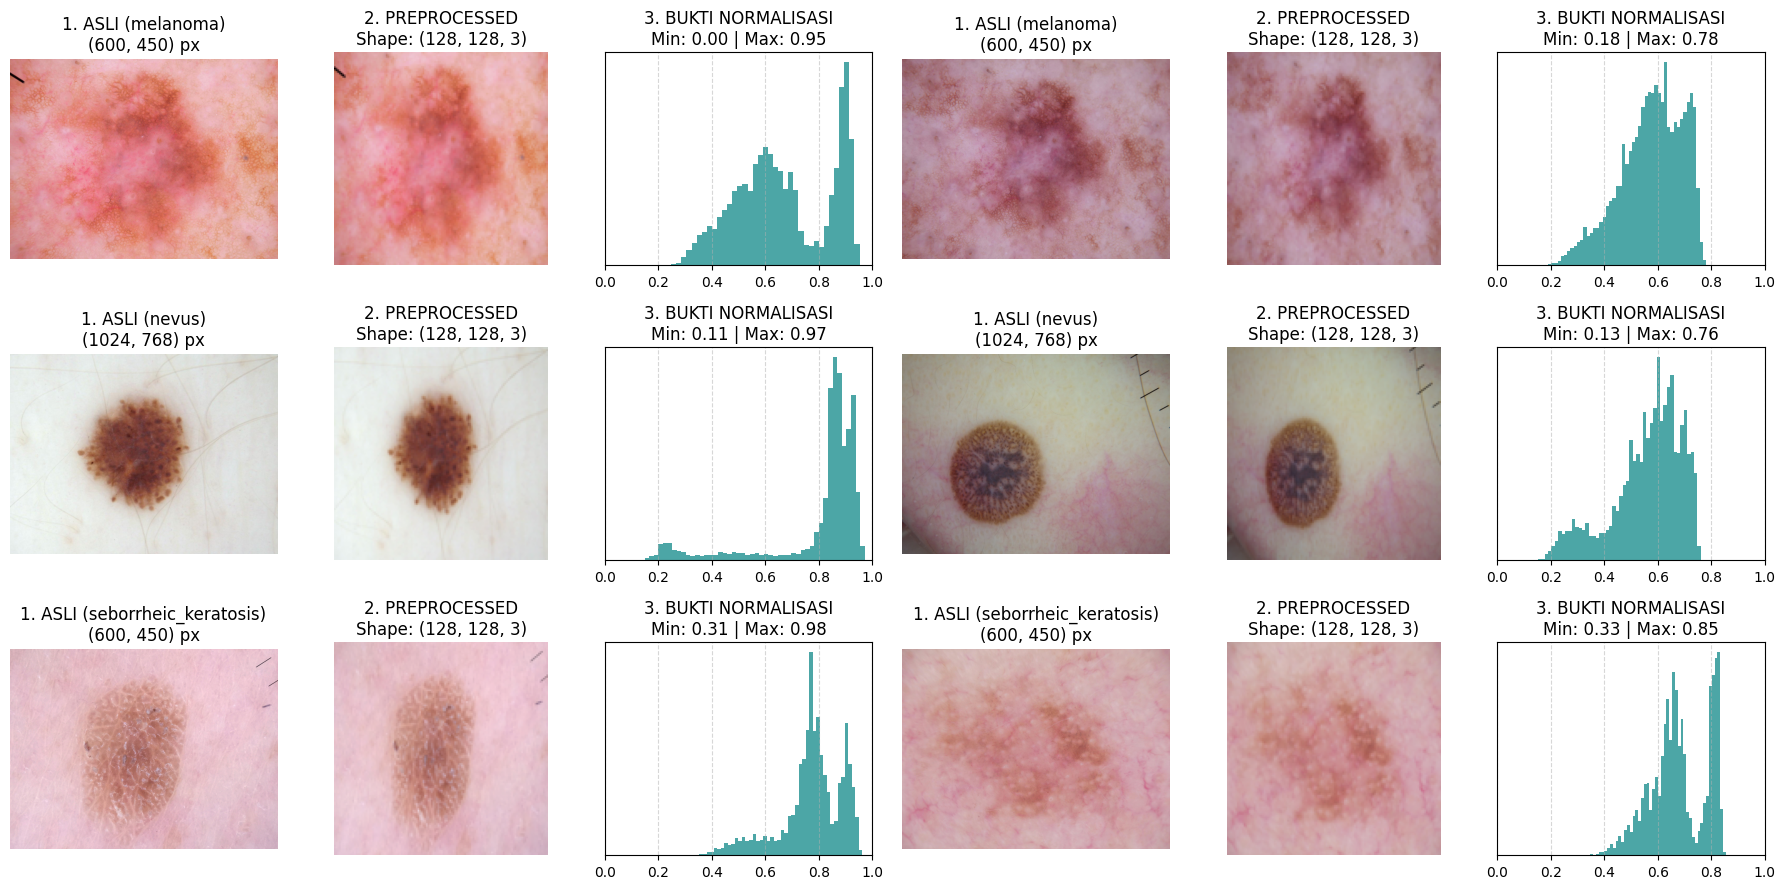

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import subprocess
import random
import io

# 1. Kumpulkan semua path dari HDFS
listing = subprocess.run(
    ["hdfs", "dfs", "-ls", "-R", HDFS_WORKDIR],
    capture_output=True, text=True, check=True
).stdout

# Kelompokkan path gambar berdasarkan nama kelas
class_names = list(label_to_index.keys())
paths_by_class = {c: [] for c in class_names}

for line in listing.splitlines():
    parts = line.split()
    if len(parts) > 0:
        path = parts[-1]
        if path.lower().endswith(('.jpg', '.jpeg', '.png')):
            label_name = path.rstrip("/").split("/")[-2]
            if label_name in paths_by_class:
                paths_by_class[label_name].append(path)

# 2. Setup Plot: 3 Baris Kelas x 6 Kolom (2 Sampel x [Asli, Preprocessed, Histogram])
samples_per_class = 2
fig, axes = plt.subplots(len(class_names), samples_per_class * 3, figsize=(18, 3 * len(class_names)))

print(f"Mengambil {samples_per_class} sampel per kelas untuk pembuktian normalisasi...\n")

for i, class_name in enumerate(class_names):
    # Pilih sampel acak untuk kelas ini
    sample_paths = random.sample(paths_by_class[class_name], samples_per_class)

    for j, sample_path in enumerate(sample_paths):
        # a. Baca bytestream file lewat subprocess CLI
        cat_result = subprocess.run(
            ["hdfs", "dfs", "-cat", sample_path],
            capture_output=True, check=True
        )
        raw_bytes = cat_result.stdout

        # b. Gambar Asli
        original_img = Image.open(io.BytesIO(raw_bytes)).convert("RGB")

        # c. Preprocessing & Normalisasi
        resized_img = original_img.resize((IMG_SIZE, IMG_SIZE))
        preprocessed_array = np.asarray(resized_img, dtype=np.float32) / 255.0

        # d. Tentukan posisi index kolom untuk sampel ini
        col_base = j * 3

        # e. [Kolom 1] Render Gambar Sebelum
        ax_original = axes[i, col_base]
        ax_original.imshow(original_img)
        ax_original.set_title(f"1. ASLI ({class_name})\n{original_img.size} px")
        ax_original.axis("off")

        # f. [Kolom 2] Render Gambar Sesudah Resize
        ax_preprocessed = axes[i, col_base + 1]
        ax_preprocessed.imshow(preprocessed_array)
        ax_preprocessed.set_title(f"2. PREPROCESSED\nShape: {preprocessed_array.shape}")
        ax_preprocessed.axis("off")

        # g. [Kolom 3] Render Histogram Normalisasi
        # Meratakan array (ravel) untuk melihat seluruh nilai piksel
        ax_hist = axes[i, col_base + 2]
        ax_hist.hist(preprocessed_array.ravel(), bins=50, color='teal', alpha=0.7)
        ax_hist.set_title(f"3. BUKTI NORMALISASI\nMin: {preprocessed_array.min():.2f} | Max: {preprocessed_array.max():.2f}")
        ax_hist.set_xlim(0, 1)  # Mengunci sumbu X agar terlihat jelas rentang 0 sampai 1
        ax_hist.set_yticks([])  # Menyembunyikan sumbu Y agar grafik lebih rapi
        ax_hist.grid(axis='x', linestyle='--', alpha=0.5)

plt.tight_layout()

# Simpan grafik lengkap ke Google Drive
vis_path = PROJECT_DIR / f"preprocessing_norm_proof_{SCENARIO_NAME}.png"
plt.savefig(vis_path)
print(f"Berhasil! Gambar beserta histogram normalisasi disimpan di: {vis_path}")

plt.show()

# **FASE 6 — Implementasi Model CNN**

### **31. Split Data**
Stratifikasi per kelas menjaga proporsi 3 kelas, sedangkan `SPLIT_SEED` tetap memastikan semua skenario memakai test set yang sama.


In [ ]:
from pyspark import StorageLevel

TRAIN_FRACTION = 0.70
VAL_FRACTION = 0.15
TEST_FRACTION = 0.15
SPLIT_SEED = 42

def stratified_split(rdd, num_classes, train_frac, val_frac, test_frac, seed):
    train_parts, val_parts, test_parts = [], [], []

    for class_idx in range(num_classes):
        class_rdd = rdd.filter(lambda item, c=class_idx: item[1] == c)
        train_rdd, val_rdd, test_rdd = class_rdd.randomSplit(
            [train_frac, val_frac, test_frac], seed=seed
        )
        train_parts.append(train_rdd)
        val_parts.append(val_rdd)
        test_parts.append(test_rdd)

    def union_all(parts):
        result = parts[0]
        for part in parts[1:]:
            result = result.union(part)
        return result

    return union_all(train_parts), union_all(val_parts), union_all(test_parts)


train_rdd, val_rdd, test_rdd = stratified_split(
    processed_rdd, NUM_CLASSES, TRAIN_FRACTION, VAL_FRACTION, TEST_FRACTION, SPLIT_SEED
)

# union mengacak ulang jumlah partisi - dikembalikan ke NUM_PARTITIONS
# karena itu variabel eksperimen yang harus konsisten di Fase 7
train_rdd = train_rdd.coalesce(NUM_PARTITIONS).persist(StorageLevel.DISK_ONLY)

def count_classes(rdd, num_classes):
    counts = rdd.map(lambda item: item[1]).countByValue()
    return [counts.get(i, 0) for i in range(num_classes)]

print("Distribusi kelas - train:", count_classes(train_rdd, NUM_CLASSES))
print("Distribusi kelas - val:", count_classes(val_rdd, NUM_CLASSES))
print("Distribusi kelas - test:", count_classes(test_rdd, NUM_CLASSES))

Distribusi kelas - train: [1157, 1308, 1044]
Distribusi kelas - val: [237, 257, 223]
Distribusi kelas - test: [240, 278, 218]


### **32. Kumpulkan Val/Test ke Driver**

In [ ]:
import numpy as np

def rdd_to_numpy(rdd):
    arrays, labels = [], []
    for image_array, label in rdd.toLocalIterator():
        arrays.append(image_array)
        labels.append(label)
    return np.array(arrays), np.array(labels)

X_val, y_val = rdd_to_numpy(val_rdd)
X_test, y_test = rdd_to_numpy(test_rdd)

from tensorflow.keras.utils import to_categorical

y_val_cat = to_categorical(y_val, num_classes=NUM_CLASSES)
y_test_cat = to_categorical(y_test, num_classes=NUM_CLASSES)

print(f"Val set: {X_val.shape}, Test set: {X_test.shape}")

Val set: (717, 128, 128, 3), Test set: (736, 128, 128, 3)


### **33. Modul Model CNN: `build_model()`**
menggunakan `ReLU` pada Conv/Dense, `Softmax` pada output, dengan urutan `Flatten → Dropout → Dense(128)`.


In [ ]:
def build_model(img_size=IMG_SIZE, num_classes=NUM_CLASSES):
    from tensorflow import keras
    from tensorflow.keras import layers

    model = keras.Sequential([
        layers.Input(shape=(img_size, img_size, 3)),

        layers.Conv2D(32, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),
        layers.Dropout(0.5),
        layers.Dense(128, activation="relu"),
        layers.Dense(num_classes, activation="softmax"),
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model

### **34. Fungsi Evaluasi: Accuracy + F1**

In [ ]:
from sklearn.metrics import f1_score


def evaluate_model(model, X, y_true_int):
    y_pred_probs = model.predict(X, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    return f1_score(y_true_int, y_pred, average="macro")

### **35. Verifikasi Modul**

In [ ]:
_test_model = build_model()
_test_model.summary()

_dummy_batch = np.zeros((4, IMG_SIZE, IMG_SIZE, 3), dtype=np.float32)
_dummy_output = _test_model.predict(_dummy_batch, verbose=0)
assert _dummy_output.shape == (4, NUM_CLASSES), f"Shape output tidak sesuai: {_dummy_output.shape}"
print(f"Output shape untuk batch size 4: {_dummy_output.shape}")

del _test_model, _dummy_batch, _dummy_output

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,027 (12.61 MB)

 Trainable params: 3,305,027 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Output shape untuk batch size 4: (4, 3)


**Fase 6** sudah lolos sanity check jika: model memiliki ±3,3 juta parameter dan output `(4, 3)` untuk 3 kelas. `_test_model` dihapus, sedangkan model sebenarnya dibuat per worker di Fase 7 dengan `build_model()`.


# **FASE 7 — Implementasi Skema Distributed Training**

### **37. Fungsi average_weights()**

In [ ]:
def average_weights(list_of_weights):
    return [
        np.mean(layer_weights, axis=0)
        for layer_weights in zip(*list_of_weights)
    ]

### **38. Fungsi train_on_partition() dan Orkestrasi Training Terdistribusi**

In [ ]:
def run_distributed_training(spark, train_rdd, num_classes, epochs, use_gpu=False):
    initial_model = build_model(num_classes=num_classes)
    initial_weights = initial_model.get_weights()
    weights_broadcast = spark.sparkContext.broadcast(initial_weights)
    del initial_model

    def train_on_partition(rows):
        import os
        if not use_gpu:
            os.environ["CUDA_VISIBLE_DEVICES"] = ""

        import numpy as np
        import tensorflow as tf
        from tensorflow.keras.utils import to_categorical

        if use_gpu:
            for gpu in tf.config.list_physical_devices("GPU"):
                try:
                    tf.config.experimental.set_memory_growth(gpu, True)
                except RuntimeError:
                    pass

        images, labels = [], []
        for image_array, label in rows:
            images.append(image_array)
            labels.append(label)

        if not images:
            return iter([])

        X = np.array(images)
        y = to_categorical(np.array(labels), num_classes=num_classes)

        model = build_model(num_classes=num_classes)
        model.set_weights(weights_broadcast.value)

        # verbose=1 agar progress per epoch tercetak di log executor worker
        history = model.fit(X, y, epochs=epochs, batch_size=32, verbose=1)

        # Kembalikan bobot dan history lokal
        return iter([(model.get_weights(), history.history)])

    start_time = time.time()
    results_collected = train_rdd.mapPartitions(train_on_partition).collect()
    elapsed_sec = time.time() - start_time

    weights_broadcast.unpersist()

    if not results_collected:
        raise RuntimeError("Tidak ada bobot yang dikembalikan - cek apakah train_rdd punya data")

    worker_weights = [res[0] for res in results_collected]
    worker_histories = [res[1] for res in results_collected]

    averaged_weights = average_weights(worker_weights)

    return averaged_weights, elapsed_sec, len(worker_weights), worker_histories

    start_time = time.time()
    worker_weights = train_rdd.mapPartitions(train_on_partition).collect()
    elapsed_sec = time.time() - start_time

    weights_broadcast.unpersist()

    if not worker_weights:
        raise RuntimeError("Tidak ada bobot yang dikembalikan - cek apakah train_rdd punya data")

    averaged_weights = average_weights(worker_weights)

    return averaged_weights, elapsed_sec, len(worker_weights)

### **39. Fungsi evaluate_global_model()**

In [ ]:
def evaluate_global_model(averaged_weights, X_test, y_test_cat, y_test_int):
    model = build_model()
    model.set_weights(averaged_weights)

    loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
    f1 = evaluate_model(model, X_test, y_test_int)

    return {"loss": float(loss), "accuracy": float(accuracy), "f1_score": float(f1)}

### **40. Jalankan Training Terdistribusi CPU**


Training terdistribusi selesai dalam 1737.48 detik
Partisi yang berhasil melatih model lokal: 2

Evaluasi model global pada test set:
  Loss      : 1.0712
  Accuracy  : 0.3791
  F1 (macro): 0.1905


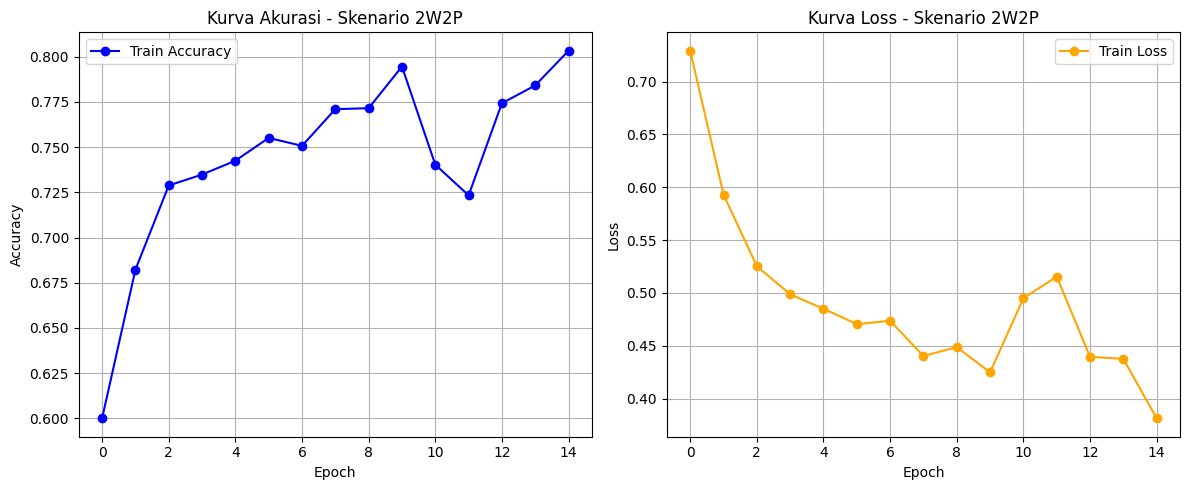

Grafik training disimpan ke: /content/drive/MyDrive/riset_kanker_kulit/training_curve_2W2P.png


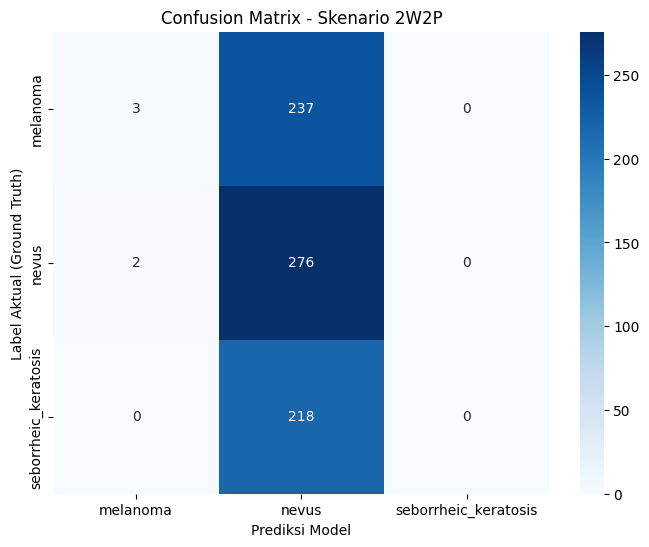

Confusion Matrix disimpan ke: /content/drive/MyDrive/riset_kanker_kulit/confusion_matrix_2W2P.png

--- Classification Report ---
                      precision    recall  f1-score   support

            melanoma       0.60      0.01      0.02       240
               nevus       0.38      0.99      0.55       278
seborrheic_keratosis       0.00      0.00      0.00       218

            accuracy                           0.38       736
           macro avg       0.33      0.34      0.19       736
        weighted avg       0.34      0.38      0.21       736



/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.13/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# 1. Jalankan training terdistribusi
averaged_weights, training_time_sec, num_partitions_completed, worker_histories = run_distributed_training(
    spark, train_rdd, NUM_CLASSES, EPOCHS
)

print(f"\nTraining terdistribusi selesai dalam {training_time_sec:.2f} detik")
print(f"Partisi yang berhasil melatih model lokal: {num_partitions_completed}")
assert num_partitions_completed == NUM_PARTITIONS

# 2. Evaluasi model global
eval_results = evaluate_global_model(averaged_weights, X_test, y_test_cat, y_test)

print("\nEvaluasi model global pada test set:")
print(f"  Loss      : {eval_results['loss']:.4f}")
print(f"  Accuracy  : {eval_results['accuracy']:.4f}")
print(f"  F1 (macro): {eval_results['f1_score']:.4f}")

# ==========================================
# 3. VISUALISASI GRAFIK TRAINING (Kurva Akurasi & Loss)
# ==========================================
# Mengambil riwayat dari partisi/worker pertama sebagai representasi kurva belajar
history = worker_histories[0]

plt.figure(figsize=(12, 5))

# Grafik Akurasi
plt.subplot(1, 2, 1)
plt.plot(history['accuracy'], label='Train Accuracy', marker='o', color='blue')
plt.title(f'Kurva Akurasi - Skenario {SCENARIO_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Grafik Loss
plt.subplot(1, 2, 2)
plt.plot(history['loss'], label='Train Loss', marker='o', color='orange')
plt.title(f'Kurva Loss - Skenario {SCENARIO_NAME}')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
chart_path = PROJECT_DIR / f"training_curve_{SCENARIO_NAME}.png"
plt.savefig(chart_path)
plt.show()
print(f"Grafik training disimpan ke: {chart_path}")

# ==========================================
# 4. EVALUASI LANJUTAN: CONFUSION MATRIX & CLASSIFICATION REPORT
# ==========================================
model_eval = build_model()
model_eval.set_weights(averaged_weights)

y_pred_probs = model_eval.predict(X_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

# Hitung Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
class_names = sorted(list(label_to_index.keys()))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title(f'Confusion Matrix - Skenario {SCENARIO_NAME}')
plt.xlabel('Prediksi Model')
plt.ylabel('Label Aktual (Ground Truth)')

cm_path = PROJECT_DIR / f"confusion_matrix_{SCENARIO_NAME}.png"
plt.savefig(cm_path)
plt.show()
print(f"Confusion Matrix disimpan ke: {cm_path}")

# Cetak Classification Report (Precision, Recall, F1-Score per kelas)
print("\n--- Classification Report ---")
print(classification_report(
    y_test,
    y_pred,
    target_names=class_names,
    zero_division=0
))

### **41. Generalisasi Logging dan Catat Hasil**

In [ ]:
RESULTS_LOG_PATH = PROJECT_DIR / "results.csv"
LOG_COLUMNS = [
    "timestamp", "scenario", "num_workers", "num_partitions", "stage",
    "elapsed_sec", "image_count", "accuracy", "f1_score", "loss",
]

def log_result(stage, elapsed_sec, image_count=None, accuracy=None, f1_score=None, loss=None):
    file_exists = RESULTS_LOG_PATH.exists()
    with open(RESULTS_LOG_PATH, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(LOG_COLUMNS)
        writer.writerow([
            time.strftime("%Y-%m-%d %H:%M:%S"),
            SCENARIO_NAME, NUM_WORKERS, NUM_PARTITIONS, stage,
            round(elapsed_sec, 3), image_count, accuracy, f1_score, loss,
        ])
    print(f"Logged '{stage}' to {RESULTS_LOG_PATH}")

# Fase 5, dipanggil ulang dengan fungsi baru:
log_result(stage="preprocessing", elapsed_sec=preprocessing_time_sec, image_count=image_count)

# Fase 7:
log_result(
    stage="training",
    elapsed_sec=training_time_sec,
    accuracy=eval_results["accuracy"],
    f1_score=eval_results["f1_score"],
    loss=eval_results["loss"],
)

Logged 'preprocessing' to /content/drive/MyDrive/riset_kanker_kulit/results.csv
Logged 'training' to /content/drive/MyDrive/riset_kanker_kulit/results.csv


### **42. Perbandingan Waktu Training: CPU vs GPU**

In [ ]:
# Ubah pemanggilan di Bagian 42 menjadi seperti ini (tambahkan underscore penampung):
_, gpu_training_time_sec, _, _ = run_distributed_training(
    spark, train_rdd, NUM_CLASSES, EPOCHS, use_gpu=True
)

print(f"Training terdistribusi CPU ({NUM_WORKERS} worker): {training_time_sec:.2f} detik")
print(f"Training terdistribusi GPU ({NUM_WORKERS} worker berbagi 1 GPU): {gpu_training_time_sec:.2f} detik")

log_result(stage="training_gpu_comparison", elapsed_sec=gpu_training_time_sec)

Training terdistribusi CPU (2 worker): 1737.48 detik
Training terdistribusi GPU (2 worker berbagi 1 GPU): 1727.24 detik
Logged 'training_gpu_comparison' to /content/drive/MyDrive/riset_kanker_kulit/results.csv
